# This is my 1st Kaggle Notebook. Im simplying trying to plot the salary range using seaborn and run Linear regression 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/salary/Salary.csv


Loading the CSV from filepath

In [2]:
sal_filepath = "/kaggle/input/salary/Salary.csv"
sal = pd.read_csv(sal_filepath)
sal.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


Below are the charts using Line plot and regression 

<AxesSubplot:title={'center':'Salary Increase Chart using Line Plot'}, xlabel='YearsExperience', ylabel='Salary'>

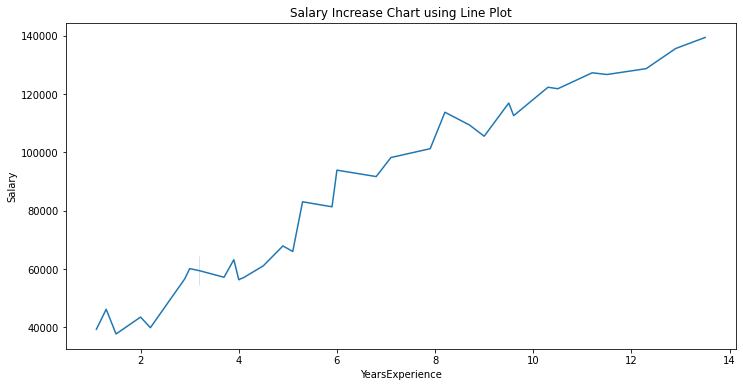

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
plt.title("Salary Increase Chart using Line Plot")
sns.lineplot(data=sal,x=sal.YearsExperience,y=sal.Salary)


<AxesSubplot:title={'center':'Salary Increase Chart using Regression Plot'}, xlabel='YearsExperience', ylabel='Salary'>

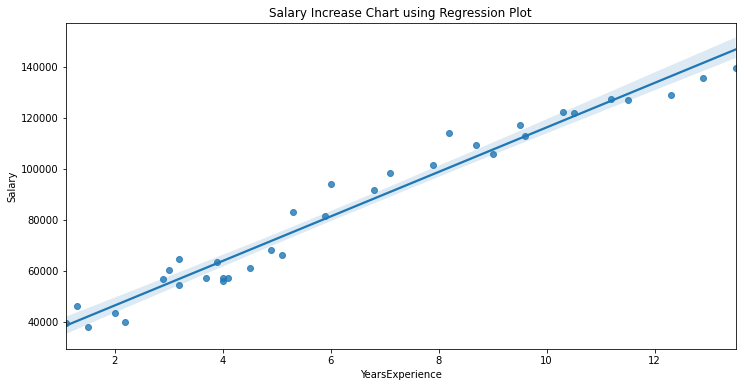

In [4]:
plt.figure(figsize=(12,6))
plt.title("Salary Increase Chart using Regression Plot")
sns.regplot(x=sal.YearsExperience,y=sal.Salary)

We have to split the Experience in X and salary in y. Make sure that the value splited is in nparray form.

In [5]:
X=sal.iloc[:,:-1].values
y=sal.iloc[:,-1].values

We are splitting the data for training and predicting the value later.
We are spliiting with 80:20 ratio 

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size = 0.2, random_state = 0)

We are importing liner_model and using fitting our train data to it.

In [7]:
from sklearn import linear_model
lreg = linear_model.LinearRegression()
lreg.fit(X_train,y_train)
print(lreg.intercept_)
print(lreg.coef_)

29445.056520181286
[8629.79240044]


We have predicited the value and stored it in predicted_val. Below you can see the table with actuals and predicted value. It is not 100% still accurate

In [8]:
predicted_val = lreg.predict(X_valid)

In [9]:
df = pd.DataFrame({'Actual': y_valid, 'Predicted': predicted_val})
df

,Actual,Predicted
0,121872,120057.876725
1,91738,88127.644843
2,66029,73456.997762
3,122391,118331.918245
4,101302,97620.416484
5,67938,71731.039282
6,63218,63101.246882


In [10]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(y_valid, predicted_val))
print('Mean Squared Error:', metrics.mean_squared_error(y_valid, predicted_val))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_valid, predicted_val)))

Mean Absolute Error: 3500.419123800644
Mean Squared Error: 16561691.220974546
Root Mean Squared Error: 4069.605782010654


Do let me know in the comments if i have done anything wrong or suggestions. Thanks